In [31]:
# IMPORTING LIBRARIES-

%matplotlib inline
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import ( accuracy_score, classification_report, confusion_matrix)

In [ ]:
# LOADING DATASET-

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
# DATA EXPLORATION-

df.shape

(7043, 21)

In [11]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [6]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [ ]:
# TARGET VARIABLE-

df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [10]:
# MAPPING TARGET VARIABLE-

df["Churn"] = df["Churn"].map({"Yes":1,"No":0})

In [ ]:
# TotalCharges COLUMN HAS MORE THEN ONE DATATYPE-

print(df["TotalCharges"].dtype)

object


In [13]:
df["TotalCharges"].apply(type).value_counts()

TotalCharges
<class 'str'>    7043
Name: count, dtype: int64

In [14]:
# CHANGING DATATYPE OF TotalCharges TO NUMERIC-

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"],errors="coerce")

df["TotalCharges"].fillna(df["TotalCharges"].median(),inplace=True)

C:\Users\akshi\AppData\Local\Temp\ipykernel_27804\1987519924.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["TotalCharges"].fillna(df["TotalCharges"].median(),inplace=True)


In [15]:
# DROPPING UNECESSARY COLUMN-

df.drop( "customerID",axis=1,inplace=True)

In [16]:
# ENCODING CATEGORICAL COLUMNS-

df = pd.get_dummies( df, drop_first=True)

In [17]:
# SPLIT FEATURES AND TARGET-

X = df.drop( "Churn",axis=1)

y = df["Churn"]

In [18]:
# TRAIN TEST SPLIT-

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42)

In [29]:
# FEATURE SCALING-

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [20]:
# TRAINING MODEL-

rf = RandomForestClassifier( n_estimators=200, random_state=42)
rf.fit( X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [21]:
# PREDICTING-

y_pred = rf.predict( X_test)

In [22]:
# EVALUATION-

print(accuracy_score(    y_test,  y_pred ))

print(classification_report( y_test, y_pred ))

0.7934705464868701
              precision    recall  f1-score   support

           0       0.82      0.91      0.87      1036
           1       0.66      0.46      0.54       373

    accuracy                           0.79      1409
   macro avg       0.74      0.69      0.70      1409
weighted avg       0.78      0.79      0.78      1409



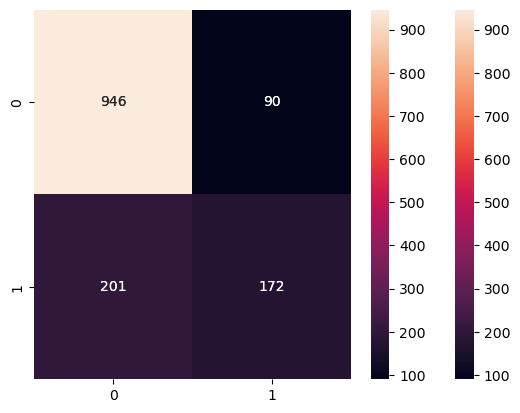

In [25]:
# CONFUSION MATRIX-

cm = confusion_matrix( y_test,y_pred)

sns.heatmap(cm,annot=True,fmt="d")

plt.show()

In [39]:
# SAVING MODEL-

joblib.dump( rf, "model/churn_model.pkl", compress=3)

joblib.dump( scaler, "model/scaler.pkl")

['model/scaler.pkl']

In [35]:
# SAVING THE PROCESSED DATASET-

df.to_csv("data/processed_churn.csv", index=False)